In [ ]:
! pip3 install shap , imblearn

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PowerTransformer, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_val_predict, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [2]:
data = pd.read_csv('Prostate_Cancer.csv')

# EDA

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 100 non-null    int64  
 1   diagnosis_result   100 non-null    object 
 2   radius             100 non-null    int64  
 3   texture            100 non-null    int64  
 4   perimeter          100 non-null    int64  
 5   area               100 non-null    int64  
 6   smoothness         100 non-null    float64
 7   compactness        100 non-null    float64
 8   symmetry           100 non-null    float64
 9   fractal_dimension  100 non-null    float64
dtypes: float64(4), int64(5), object(1)
memory usage: 7.9+ KB


In [ ]:
data.describe() 

,id,radius,texture,perimeter,area,smoothness,compactness,symmetry,fractal_dimension
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,50.500000,16.850000,18.230000,96.780000,702.880000,0.102730,0.126700,0.193170,0.064690
std,29.011492,4.879094,5.192954,23.676089,319.710895,0.014642,0.061144,0.030785,0.008151
min,1.000000,9.000000,11.000000,52.000000,202.000000,0.070000,0.038000,0.135000,0.053000
25%,25.750000,12.000000,14.000000,82.500000,476.750000,0.093500,0.080500,0.172000,0.059000
50%,50.500000,17.000000,17.500000,94.000000,644.000000,0.102000,0.118500,0.190000,0.063000
75%,75.250000,21.000000,22.250000,114.250000,917.000000,0.112000,0.157000,0.209000,0.069000
max,100.000000,25.000000,27.000000,172.000000,1878.000000,0.143000,0.345000,0.304000,0.097000


In [ ]:
data['diagnosis_result'].value_counts()

,count
diagnosis_result,
M,62
B,38


In [4]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['diagnosis_result'] = le.fit_transform(data['diagnosis_result'])
print(f"\nLabel encoding map: {dict(zip(le.classes_, le.transform(le.classes_)))}")


Label encoding map: {'B': np.int64(0), 'M': np.int64(1)}


In [5]:
X=data.drop(['id','diagnosis_result'],axis=1)
y=data['diagnosis_result']

## Box plot analysis and Data visualization
- Here we performed to look for any outliers
- Data visualization to look for any skewness within data

<Figure size 1500x1000 with 0 Axes>

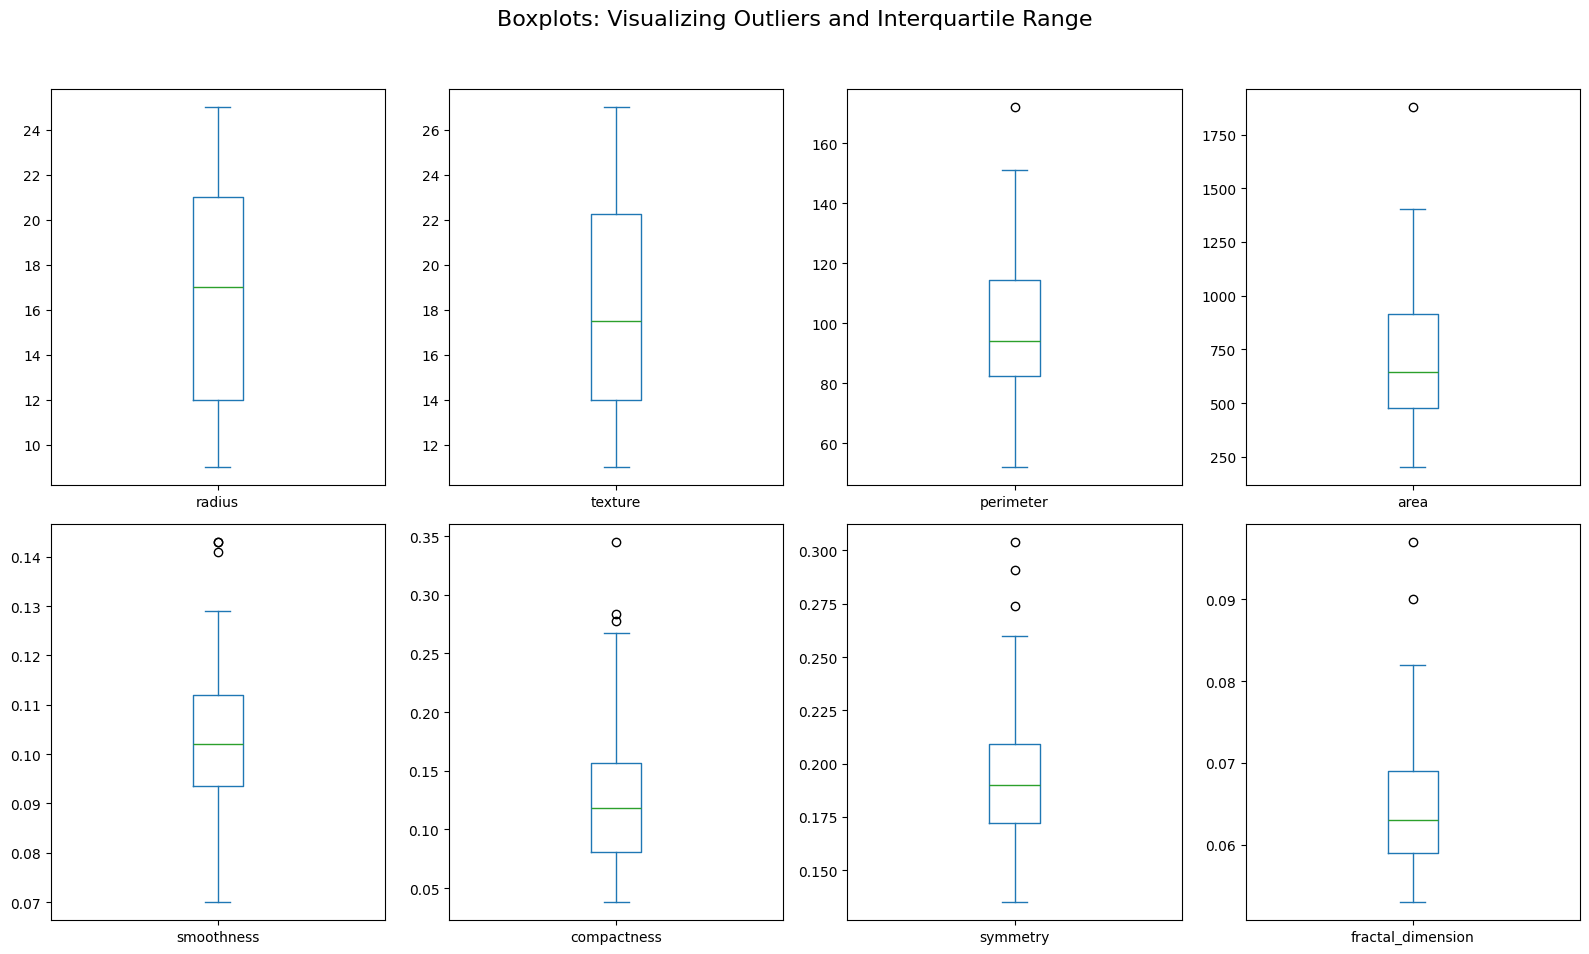

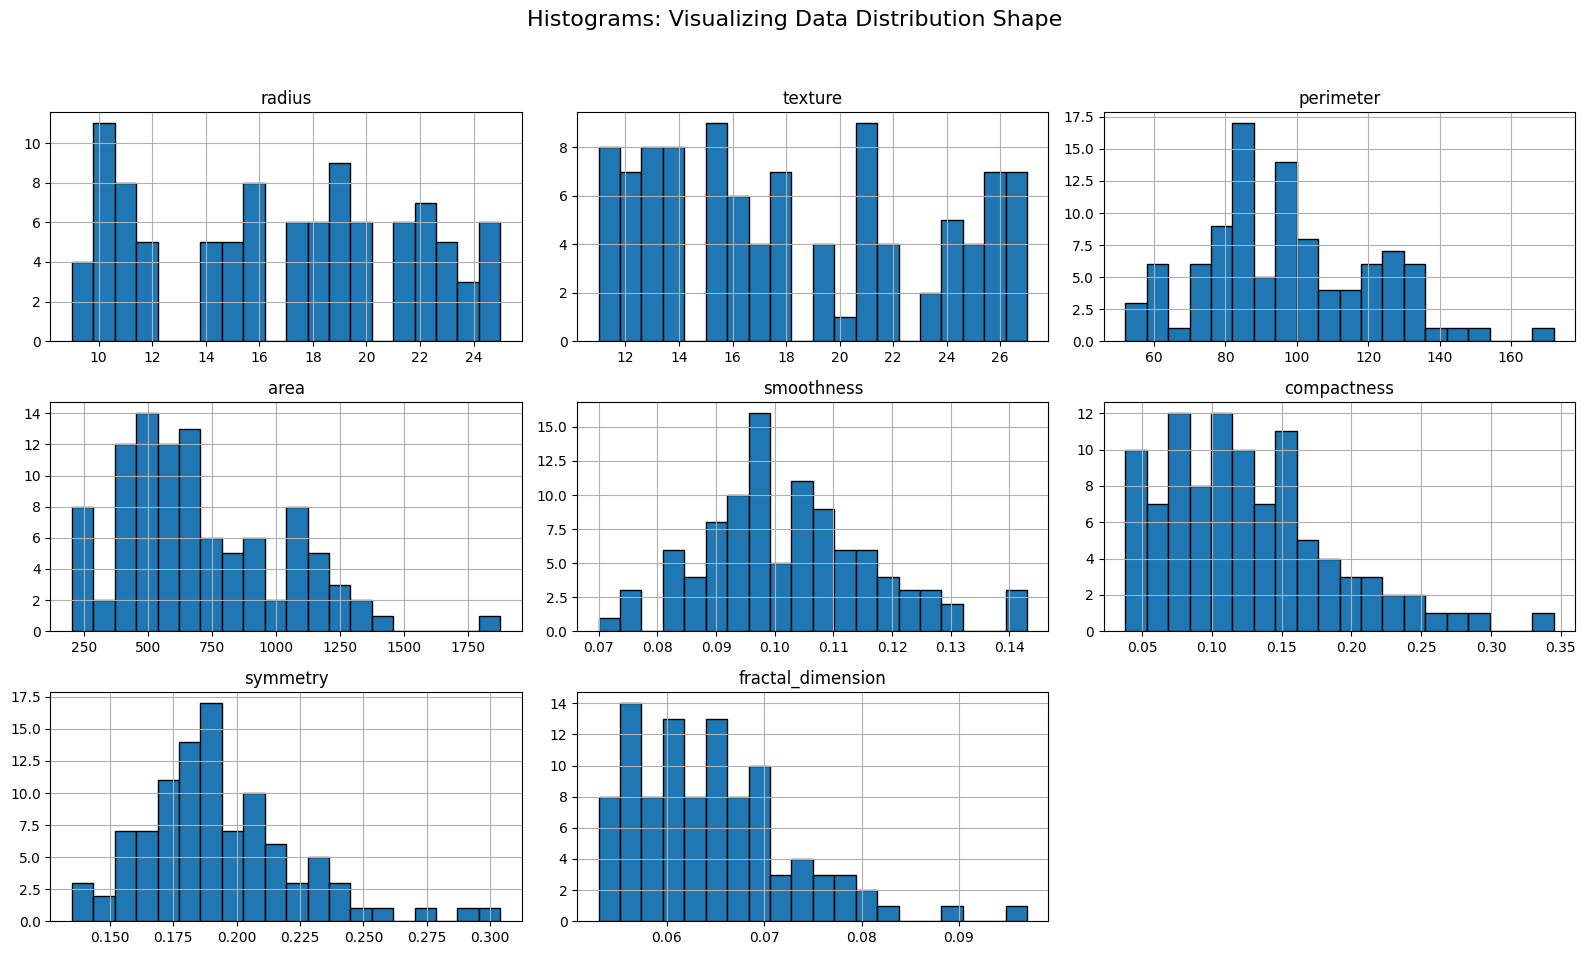

In [6]:
plt.figure(figsize=(15, 10))
X.plot(kind='box', subplots=True, layout=(2, 4), sharex=False, sharey=False, figsize=(16, 10))
plt.suptitle('Boxplots: Visualizing Outliers and Interquartile Range', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 5. Visualizing with Histograms (Best for seeing the shape/distribution)
X.hist(figsize=(16, 10), bins=20, edgecolor='black')
plt.suptitle('Histograms: Visualizing Data Distribution Shape', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

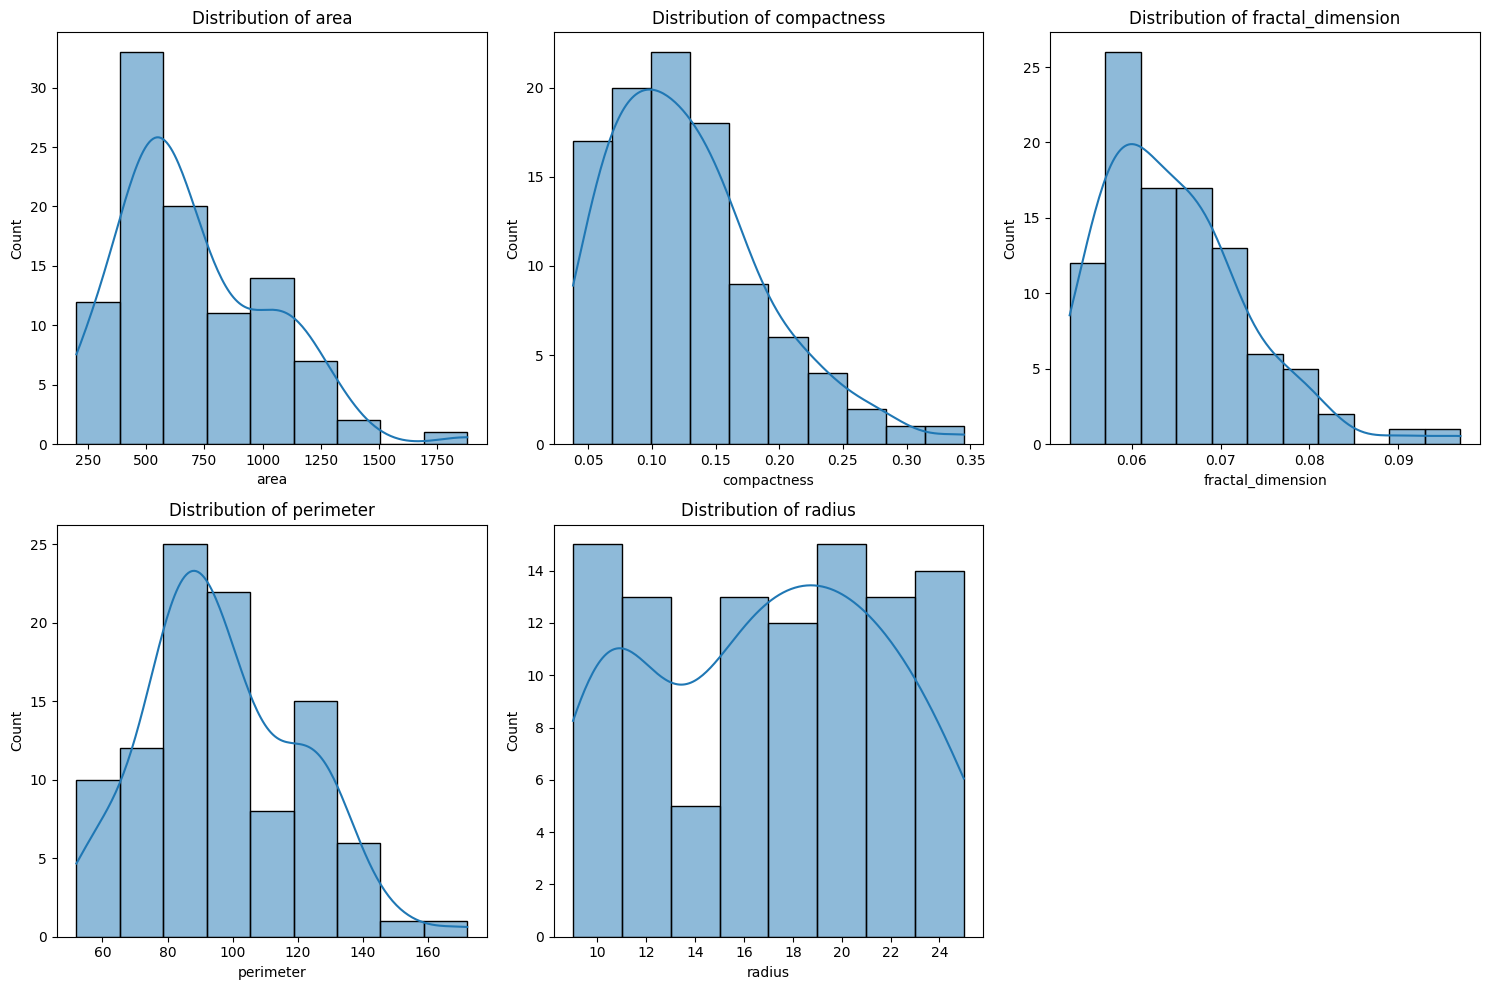

In [7]:
# 1) Distribution of data for skewed features
skewed_features = ['area', 'compactness', 'fractal_dimension', 'perimeter', 'radius']
plt.figure(figsize=(15, 10))
for i, feature in enumerate(skewed_features, 1):
    plt.subplot(2, 3, i)
    sns.histplot(data[feature], kde=True)
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

### here we looked for distribution of features for each label 

/tmp/ipykernel_4182/1875476479.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='diagnosis_result', y=feature, data=data, palette='Set2')
/tmp/ipykernel_4182/1875476479.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='diagnosis_result', y=feature, data=data, palette='Set2')
/tmp/ipykernel_4182/1875476479.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='diagnosis_result', y=feature, data=data, palette='Set2')
/tmp/ipykernel_4182/1875476479.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will

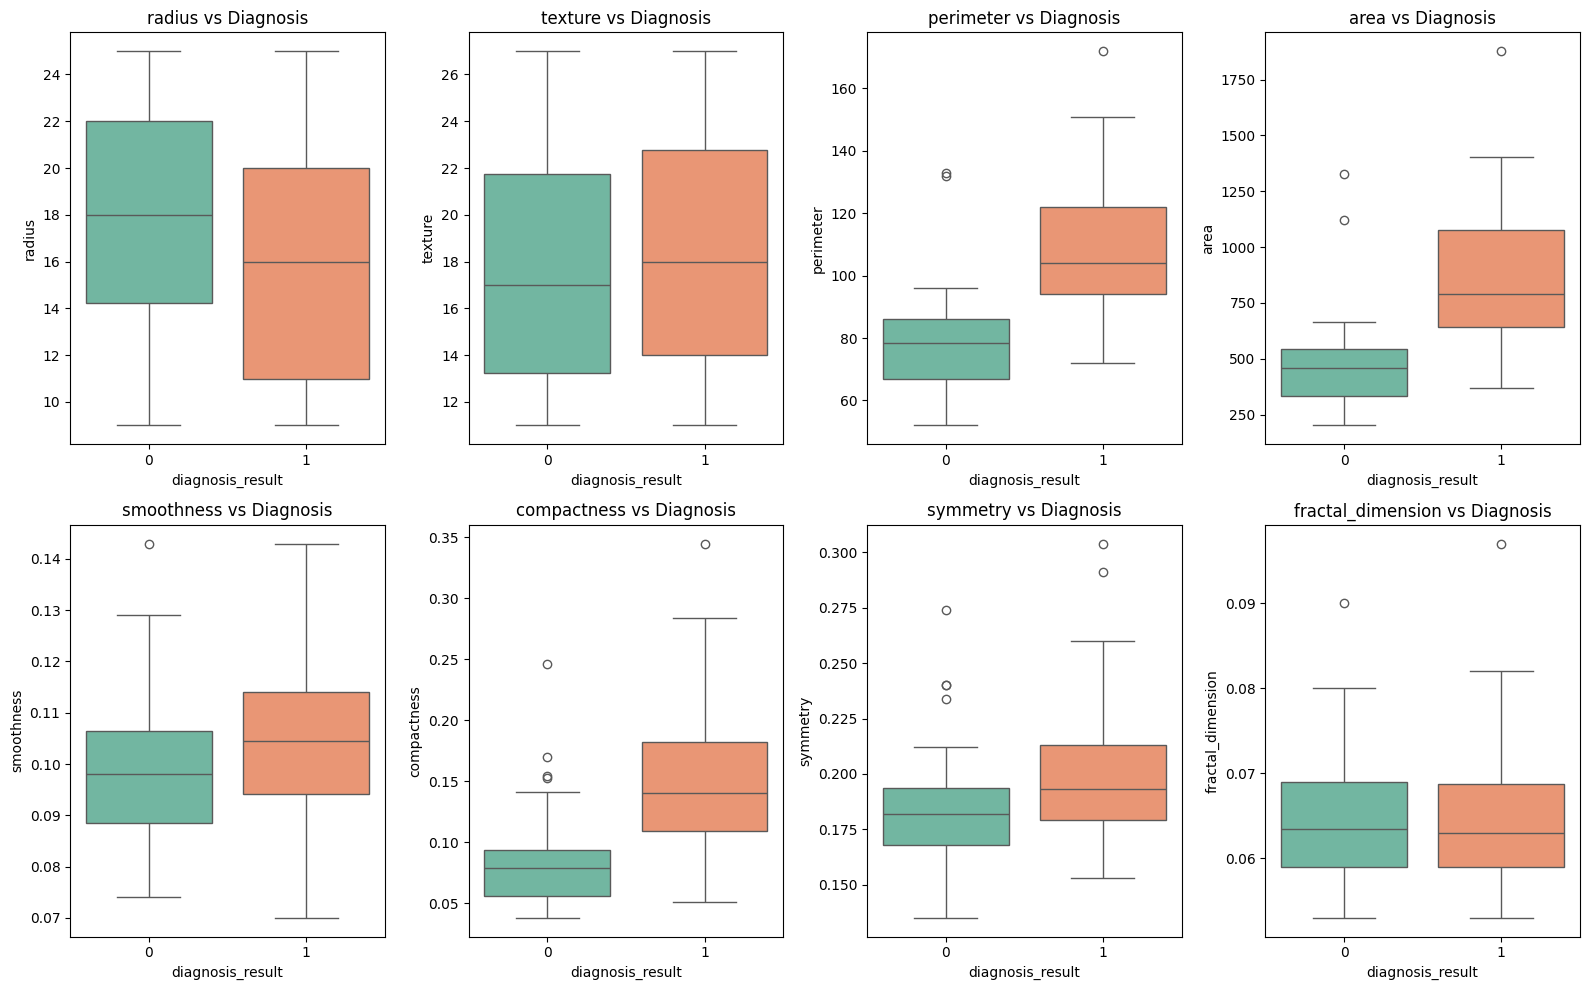

In [ ]:
plt.figure(figsize=(16, 10))
for i, feature in enumerate(X, 1):
    plt.subplot(2, 4, i)
    sns.boxplot(x='diagnosis_result', y=feature, data=data, palette='Set2')
    plt.title(f'{feature} vs Diagnosis')

plt.tight_layout()
plt.show()

### Correlation analysis

- We found compactness , area and perimeter to be highly correlated to target value both from heatmap and random forest classifier feature analysis

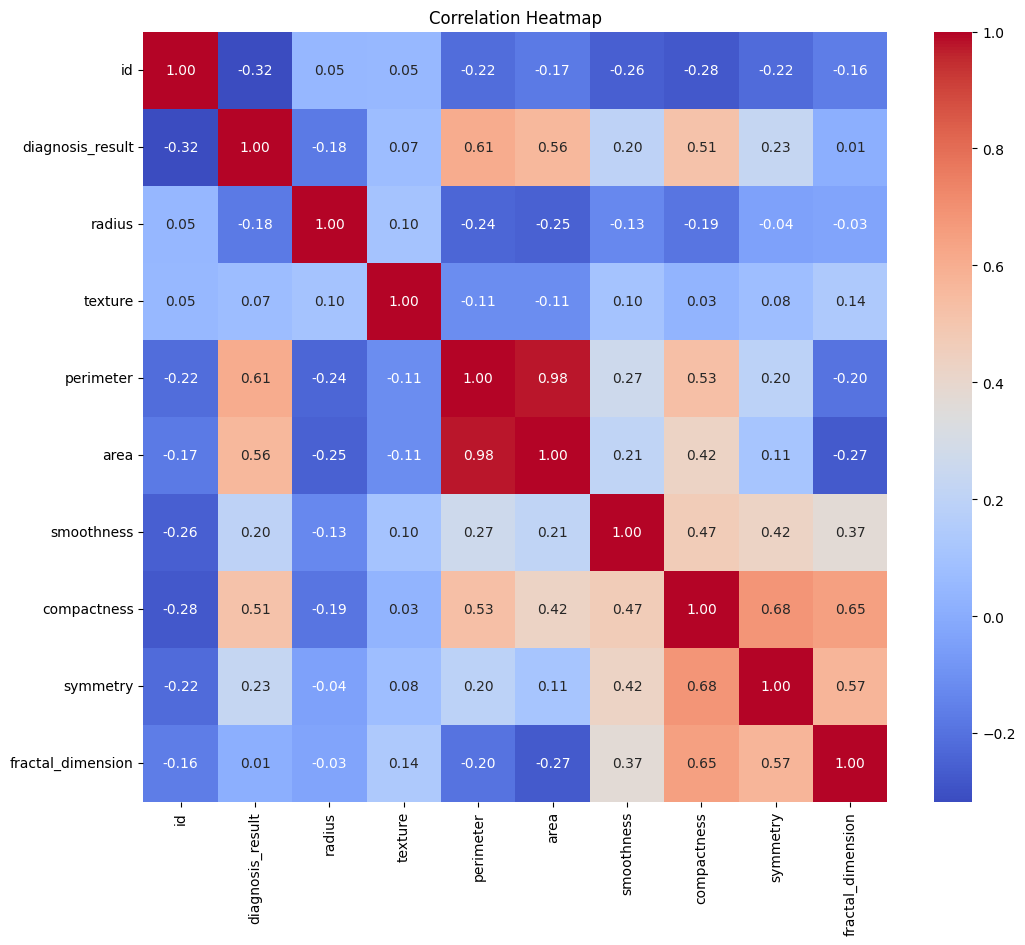

In [8]:
corr_matrix = data.corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X, y)

importance = pd.Series(model.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False))

perimeter            0.274992
area                 0.217426
compactness          0.195521
symmetry             0.084791
smoothness           0.084344
fractal_dimension    0.053480
radius               0.046542
texture              0.042903
dtype: float64


# Model Training

## Defining models to be used

In [59]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

lr = LogisticRegression(C=1, penalty='l2', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5, weights='distance')
dt = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)
rf = RandomForestClassifier(n_estimators=300, max_depth=5, random_state=42)
svc = SVC(C=0.5, random_state=42)

base_models = [
    ('rf', rf),
    ('svc', svc),
    ('dt',dt ) 
]

# 2. Define the Stacking meta-model
stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=lr,
    cv=5 # 5-fold cross-validation for the blending step
)

models = {
        "Logistic Regression": lr,
        "KNN": knn,
        "Decision Tree":dt ,
        "Random Forest": rf,
        "SVM": svc,
        "stacking classifier":stacking_clf
    }

## Model testing function 

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report
from imblearn.pipeline import Pipeline 

def model_testing(X, y, pipeline_steps, models, model_confusion_matrix, trained_pipeline):

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for name, model in models.items():
        print(f"\n{'='*20} {name} {'='*20}")

        pipeline = Pipeline(pipeline_steps + [('model', model)])

        # Cross-val predictions
        y_pred = cross_val_predict(pipeline, X, y, cv=cv, n_jobs=-1)

        cf = confusion_matrix(y, y_pred)

        print("Confusion Matrix:")
        print(cf)
        print("\nClassification Report:")
        print(classification_report(y, y_pred))

        model_confusion_matrix[name] = cf

        # ✅ Train final pipeline on full data
        pipeline.fit(X, y)
        trained_pipeline[name] = pipeline

## pipeline 1

In [61]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

pipeline = [
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler())
]

model_confusion_matrix1 = {}
trained_pipeline1 = {}

model_testing(X, y, pipeline, models, model_confusion_matrix1, trained_pipeline1)


==================== Logistic Regression ====================


/Users/ramlanjekar/Documents/MyProjects/learning_small_projects/personal_agent/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/ramlanjekar/Documents/MyProjects/learning_small_projects/personal_agent/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/ramlanjekar/Documents/MyProjects/learning_small_projects/

Confusion Matrix:
[[32  6]
 [11 51]]

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.84      0.79        38
           1       0.89      0.82      0.86        62

    accuracy                           0.83       100
   macro avg       0.82      0.83      0.82       100
weighted avg       0.84      0.83      0.83       100


==================== KNN ====================
Confusion Matrix:
[[29  9]
 [11 51]]

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.76      0.74        38
           1       0.85      0.82      0.84        62

    accuracy                           0.80       100
   macro avg       0.79      0.79      0.79       100
weighted avg       0.80      0.80      0.80       100


==================== Decision Tree ====================
Confusion Matrix:
[[25 13]
 [10 52]]

Classification Report:
              precision    recall  f1-score   support

    

/Users/ramlanjekar/Documents/MyProjects/learning_small_projects/personal_agent/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/ramlanjekar/Documents/MyProjects/learning_small_projects/personal_agent/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/ramlanjekar/Documents/MyProjects/learning_small_projects/

Confusion Matrix:
[[28 10]
 [ 7 55]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.74      0.77        38
           1       0.85      0.89      0.87        62

    accuracy                           0.83       100
   macro avg       0.82      0.81      0.82       100
weighted avg       0.83      0.83      0.83       100



/Users/ramlanjekar/Documents/MyProjects/learning_small_projects/personal_agent/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


## pipeline 2

In [ ]:
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.compose import ColumnTransformer

# Define your skewed columns
skewed_cols = ['area', 'compactness', 'fractal_dimension', 'perimeter']

# Remaining columns
normal_cols = [col for col in X.columns if col not in skewed_cols]

# ColumnTransformer — YeoJohnson on skewed, passthrough rest
col_transformer = ColumnTransformer([
    ('yeo', PowerTransformer(method='yeo-johnson'), skewed_cols),
    ('pass', 'passthrough', normal_cols)
])

# Pipeline steps
pipeline_steps_v2 = [
    ('smote', SMOTE(random_state=42)),
    ('col_transform', col_transformer),   # YeoJohnson on skewed cols only
    ('scaler', StandardScaler())           # StandardScaler over all after
]

model_confusion_matrix2 = {}
trained_pipeline2 = {}

model_testing(X, y, pipeline_steps_v2,models,model_confusion_matrix2,trained_pipeline2)


==================== Logistic Regression ====================
Confusion Matrix:
[[32  6]
 [ 9 53]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.84      0.81        38
           1       0.90      0.85      0.88        62

    accuracy                           0.85       100
   macro avg       0.84      0.85      0.84       100
weighted avg       0.85      0.85      0.85       100


==================== KNN ====================
Confusion Matrix:
[[29  9]
 [12 50]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.76      0.73        38
           1       0.85      0.81      0.83        62

    accuracy                           0.79       100
   macro avg       0.78      0.78      0.78       100
weighted avg       0.79      0.79      0.79       100


==================== Decision Tree ====================
Confusion Matrix:
[[26 12]
 [11 51]]

Classification Repo

/Users/ramlanjekar/Documents/MyProjects/learning_small_projects/personal_agent/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/ramlanjekar/Documents/MyProjects/learning_small_projects/personal_agent/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/ramlanjekar/Documents/MyProjects/learning_small_projects/

Confusion Matrix:
[[29  9]
 [ 9 53]]

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.76      0.76        38
           1       0.85      0.85      0.85        62

    accuracy                           0.82       100
   macro avg       0.81      0.81      0.81       100
weighted avg       0.82      0.82      0.82       100


==================== SVM ====================
Confusion Matrix:
[[29  9]
 [11 51]]

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.76      0.74        38
           1       0.85      0.82      0.84        62

    accuracy                           0.80       100
   macro avg       0.79      0.79      0.79       100
weighted avg       0.80      0.80      0.80       100


==================== stacking classifier ====================
Confusion Matrix:
[[30  8]
 [ 8 54]]

Classification Report:
              precision    recall  f1-score   support

/Users/ramlanjekar/Documents/MyProjects/learning_small_projects/personal_agent/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/ramlanjekar/Documents/MyProjects/learning_small_projects/personal_agent/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/ramlanjekar/Documents/MyProjects/learning_small_projects/

# Comparison of Pipeline 1 and 2

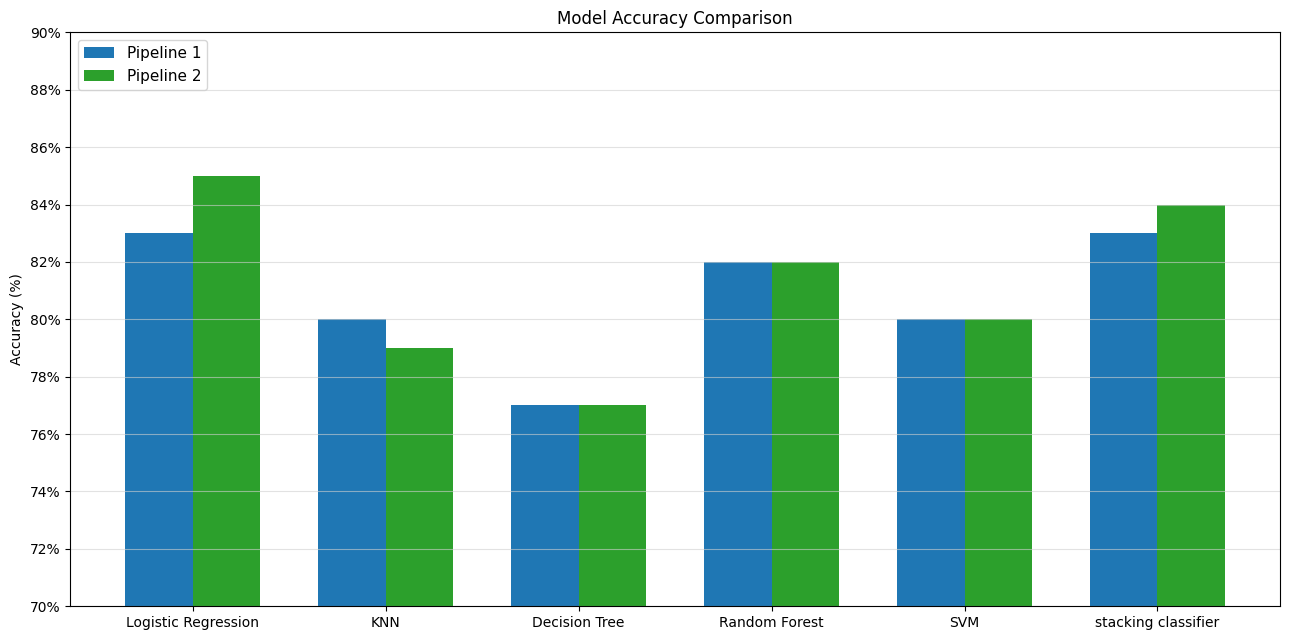

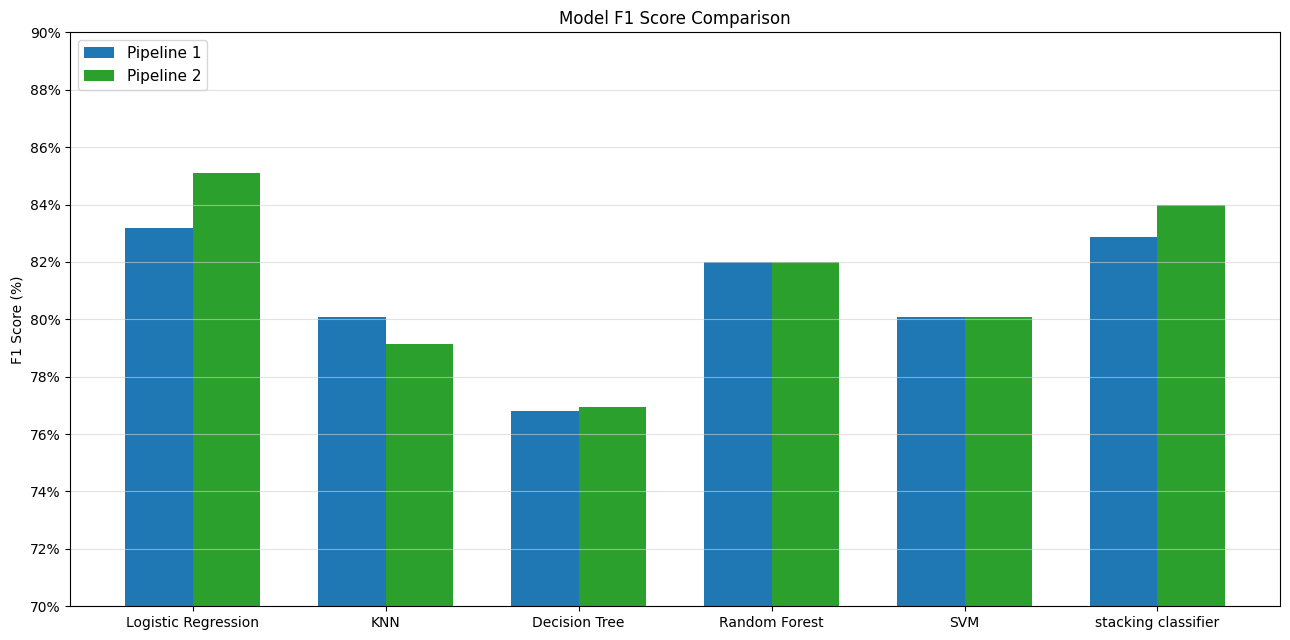

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

# ---- helper function ----
def compute_metrics_from_cm(cm):
    accuracy = np.trace(cm) / np.sum(cm)
    y_true, y_pred = [], []
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            y_true += [i] * cm[i, j]
            y_pred += [j] * cm[i, j]
    f1 = f1_score(y_true, y_pred, average="weighted")
    return accuracy * 100, f1 * 100

# Assuming your dictionaries are already defined
models = list(pipeline1_dict.keys())

acc1, acc2 = [], []
f1_1, f1_2 = [], []

for model in models:
    a1, f1score1 = compute_metrics_from_cm(pipeline1_dict[model])
    a2, f1score2 = compute_metrics_from_cm(pipeline2_dict[model])
    acc1.append(a1)
    acc2.append(a2)
    f1_1.append(f1score1)
    f1_2.append(f1score2)

x = np.arange(len(models))
width = 0.35

# ================== GRAPH 1: Accuracy (exactly like your image) ==================
plt.figure(figsize=(13, 6.5))                    # wider + taller for clean look
plt.bar(x - width/2, acc1, width, color='#1f77b4', label='Pipeline 1')   # exact blue
plt.bar(x + width/2, acc2, width, color='#2ca02c', label='Pipeline 2')   # exact green

plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")
plt.xticks(x, models, rotation=0, ha='center')   # horizontal labels like in the image
plt.yticks(np.arange(70, 91, 2), [f"{y}%" for y in np.arange(70, 91, 2)])  # exact % ticks

plt.ylim(70, 90)
plt.grid(axis='y', linestyle='-', linewidth=0.8, alpha=0.6, color='#d0d0d0')  # light grid like your screenshot

plt.legend(loc='upper left', frameon=True, fontsize=11)
plt.tight_layout()
plt.show()

# ================== GRAPH 2: F1 Score (same style as the image) ==================
plt.figure(figsize=(13, 6.5))
plt.bar(x - width/2, f1_1, width, color='#1f77b4', label='Pipeline 1')
plt.bar(x + width/2, f1_2, width, color='#2ca02c', label='Pipeline 2')

plt.ylabel("F1 Score (%)")
plt.title("Model F1 Score Comparison")
plt.xticks(x, models, rotation=0, ha='center')
plt.yticks(np.arange(70, 91, 2), [f"{y}%" for y in np.arange(70, 91, 2)])

plt.ylim(70, 90)
plt.grid(axis='y', linestyle='-', linewidth=0.8, alpha=0.6, color='#d0d0d0')

plt.legend(loc='upper left', frameon=True, fontsize=11)
plt.tight_layout()
plt.show()

# Hyperparameter Tunning of best model

In [69]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# ------------------ 1. Pipeline ------------------
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('col_transform', col_transformer),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=42, max_iter=1000))
])

# ------------------ 2. Param Grid (around your base model) ------------------
param_grid = [
    {
        'model__penalty': ['l2'],
        'model__C': [0.1, 1, 10],                 # around your base C=1
        'model__solver': ['lbfgs']
    },
    {
        'model__penalty': ['l1'],
        'model__C': [0.1, 1, 10],
        'model__solver': ['liblinear']
    }
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ------------------ 3. GridSearch ------------------
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

grid.fit(X, y)

print("\nBest Params:", grid.best_params_)

# ------------------ 4. CV Predictions (FULL DATA like model_testing) ------------------
best_model = grid.best_estimator_

y_pred = cross_val_predict(best_model, X, y, cv=cv, n_jobs=-1)

# ------------------ 5. Evaluation ------------------
cf = confusion_matrix(y, y_pred)

print("\nConfusion Matrix:")
print(cf)

print("\nClassification Report:")
print(classification_report(y, y_pred))

f1 = f1_score(y, y_pred, average='weighted')
print("\nF1 Score:", f1)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


/Users/ramlanjekar/Documents/MyProjects/learning_small_projects/personal_agent/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/ramlanjekar/Documents/MyProjects/learning_small_projects/personal_agent/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/ramlanjekar/Documents/MyProjects/learning_small_projects/


Best Params: {'model__C': 1, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}

Confusion Matrix:
[[32  6]
 [ 9 53]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.84      0.81        38
           1       0.90      0.85      0.88        62

    accuracy                           0.85       100
   macro avg       0.84      0.85      0.84       100
weighted avg       0.85      0.85      0.85       100


F1 Score: 0.8509885971335913


/Users/ramlanjekar/Documents/MyProjects/learning_small_projects/personal_agent/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/ramlanjekar/Documents/MyProjects/learning_small_projects/personal_agent/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/ramlanjekar/Documents/MyProjects/learning_small_projects/personal_agent/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid t

# Shap analysis of best model

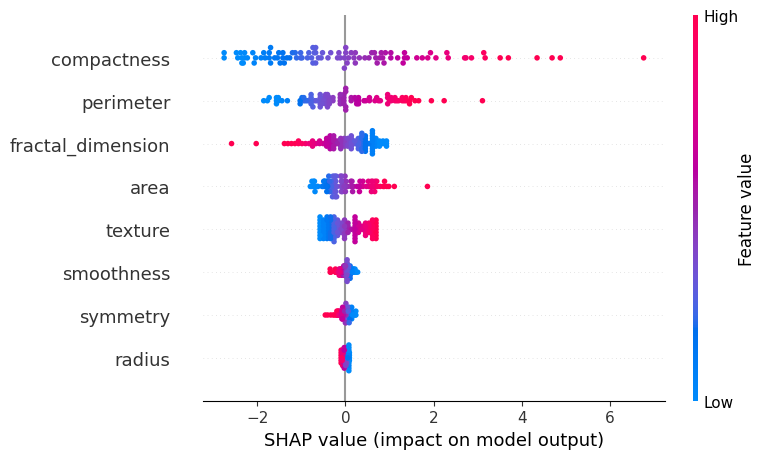

In [72]:
import shap

pipe = trained_pipeline1["Logistic Regression"]

scaler = pipe.named_steps["scaler"]
model = pipe.named_steps["model"]

X_transformed = scaler.transform(X)

# ✅ Correct explainer
explainer = shap.LinearExplainer(model, X_transformed)

shap_values = explainer.shap_values(X_transformed)

# For binary classification → no [1] needed
shap.summary_plot(shap_values, X_transformed, feature_names=X.columns)